# EDA: USGS earthquake catalogue

**Goal:** understand the raw catalogue first, then decide how to turn events into features for clustering.

**Data** (USGS ComCat, 2023-01-01 to 2023-12-31, magnitude 4.5 and above, whole world).

Download first, from the project root: `python -m quake.usgs`

Kernel: "Python (sc4020-earthquake)".

**Terms used in this notebook**

| Term | Meaning |
|---|---|
| event | One row of the catalogue: one earthquake (or other seismic event) with a time, location, depth and magnitude |
| epicentre | The point on the Earth's surface above where the earthquake started; given by `latitude` and `longitude` |
| magnitude | A logarithmic measure of earthquake size at its source; one unit up is about 32 times more energy |
| great-circle distance | The shortest distance between two points along the Earth's surface, computed here with the haversine formula |
| nearest-neighbour distance | For one event, the great-circle distance to the closest other event |
| aftershock sequence | Many smaller earthquakes that follow a large one in the same area over days to months |

**Contents**
1. Raw data: columns, types and quality
2. What the catalogue leaves out
3. Raw data visualised
4. Depth values
5. From coordinates to features
6. Spacing between events (density)
7. Events per region
8. Outliers and extremes
9. Stability over time
10. Minimum magnitude threshold
11. Dimensionality
12. Summary of preprocessing decisions

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from quake.eda import grid_cell_counts, magnitude_threshold_table, region_from_place
from quake.features import EARTH_RADIUS_KM, haversine_km, nearest_neighbour_km, to_unit_vectors
from quake.usgs import catalogue_path, load_earthquakes

%matplotlib inline
pd.set_option("display.precision", 3)
pd.set_option("display.width", 200)

## 1. Raw data: columns, types and quality

In [2]:
raw = pd.read_csv(catalogue_path())
print(catalogue_path().name, raw.shape)
raw.head(3).T

usgs_2023-01-01_2024-01-01_m4.5.csv (7651, 22)


,0,1,2
time,2023-01-01T01:41:43.755Z,2023-01-01T03:16:14.442Z,2023-01-01T05:27:09.979Z
latitude,7.14,-6.707,17.453
longitude,126.738,155.232,93.425
depth,79.194,35.0,39.85
mag,4.5,5.4,4.7
magType,mb,mww,mb
nst,32.0,130.0,45.0
gap,104.0,36.0,85.0
dmin,1.152,3.946,3.459
rms,0.47,0.68,0.5


### Column dictionary

Definitions quoted from the USGS ComCat event terms page (`earthquake.usgs.gov/data/comcat/data-eventterms.php`).
The page did not return definitions for `time`, `latitude`, `longitude`, `id` and `type`; those rows describe what the file contains.

| Column | Meaning (USGS) | Example |
|---|---|---|
| `time` | Origin time of the event, ISO 8601 in UTC (from the file) | `2023-01-01T01:41:43.755Z` |
| `latitude`, `longitude` | Epicentre in decimal degrees (from the file) | `12.2725`, `143.3492` |
| `depth` | "Depth of the event in kilometers." Poorly constrained depths may be set to a fixed value: "33 km is often used as a default depth for earthquakes determined to be shallow", "default depths of 5 or 10 km are often used in mid-continental areas" | `30.121` |
| `mag` | "The magnitude for the event." Logarithmic | `4.6` |
| `magType` | "The method or algorithm used to calculate the preferred magnitude for the event." | `mb` |
| `nst` | "The total number of seismic stations used to determine earthquake location." | `24` |
| `gap` | "The largest azimuthal gap between azimuthally adjacent stations (in degrees)." | `60` |
| `dmin` | "Horizontal distance from the epicenter to the nearest station (in degrees). 1 degree is approximately 111.2 kilometers." | `1.977` |
| `rms` | "The root-mean-square (RMS) travel time residual, in sec, using all weights." | `1.11` |
| `net` | "The ID of a data contributor. Identifies the network considered to be the preferred source of information for this event." | `us` |
| `id` | Event identifier (from the file) | `us6000m2x2` |
| `updated` | "Time when the event was most recently updated." (The page says milliseconds since the epoch; the CSV gives ISO 8601.) | `2024-03-02T21:39:37.040Z` |
| `place` | "Textual description of named geographic region near to the event." | `180 km SW of Merizo Village, Guam` |
| `type` | "Type of seismic event." | `earthquake` |
| `horizontalError` | "Uncertainty of reported location of the event in kilometers." | `8.98` |
| `depthError` | "Uncertainty of reported depth of the event in kilometers." | `5.924` |
| `magError` | "Uncertainty of reported magnitude of the event." | `0.141` |
| `magNst` | "The total number of seismic stations used to calculate the magnitude for this earthquake." | `15` |
| `status` | "Indicates whether the event has been reviewed by a human." `automatic` or `reviewed` | `reviewed` |
| `locationSource` | "The network that originally authored the reported location of this event." | `us` |
| `magSource` | "Network that originally authored the reported magnitude for this event." | `us` |

### Data types, missing values and unique values

In [3]:
def column_overview(frame):
    return pd.DataFrame(
        {
            "dtype": frame.dtypes.astype(str),
            "missing": frame.isna().sum(),
            "missing %": 100 * frame.isna().mean(),
            "unique": frame.nunique(),
            "example": frame.iloc[0],
        }
    )


column_overview(raw)

,dtype,missing,missing %,unique,example
time,str,0,0.000,7651,2023-01-01T01:41:43.755Z
latitude,float64,0,0.000,7593,7.14
longitude,float64,0,0.000,7599,126.738
depth,float64,0,0.000,3810,79.194
mag,float64,0,0.000,46,4.5
magType,str,0,0.000,9,mb
nst,float64,30,0.392,291,32.0
gap,float64,30,0.392,226,104.0
dmin,float64,33,0.431,4821,1.152
rms,float64,0,0.000,131,0.47


**Observations**

- 7,651 events and 22 columns; `id` has 7,651 unique values, so there is one row per event.
- Missing values occur only in 6 station and error columns, all under 1.2%: `nst` 30, `gap` 30, `dmin` 33, `horizontalError` 31, `magError` 90 (1.18%), `magNst` 78 (1.02%). Time, coordinates, depth and magnitude are complete.
- `nst`, `gap` and `magNst` are station counts and angles stored as `float64` because of those blanks (pandas cannot hold a blank in an integer column).
- `time` is text; it is parsed with `pd.to_datetime` where it is used (sections 1 and 3).
- `mag` has only 46 distinct values between 4.5 and 7.8: magnitudes are rounded.

### Categorical columns

In [4]:
for column in ["type", "status", "magType", "net", "locationSource", "magSource"]:
    display(raw[column].value_counts().rename_axis(column).to_frame("events").T)

type,earthquake,volcanic eruption
events,7643,8


status,reviewed
events,7651


magType,mb,mww,mwr,mw,ml,mwb,mwc,ml(texnet),mwp
events,6158,1221,244,13,9,3,1,1,1


net,us,ak,nc,pr,hv,ci,tx,nn
events,7598,30,9,5,3,3,2,1


locationSource,us,ak,nc,pr,hv,ci,tx,nn
events,7598,30,9,5,3,3,2,1


magSource,us,guc,ak,nc,pr,hv,ci,tx,nn
events,7551,47,30,9,5,3,3,2,1


**Observations**

- `type`: 7,643 `earthquake` and 8 `volcanic eruption`. `status`: all 7,651 are `reviewed` (looked at by a human).
- `magType`: `mb` for 6,158 events (80.5%), `mww` 1,221, `mwr` 244, and 6 other methods with 13 or fewer events each. Magnitudes computed by different methods are mixed in one column; magnitude is not a clustering feature, so this matters only for the threshold in section 10.
- `net`: `us` is the preferred source for 7,598 events (99.3%); 7 other networks share the remaining 53. `locationSource` has exactly the same counts. `magSource` adds `guc` (47 events), which the USGS page does not define.

### Numeric columns

In [5]:
numeric = ["latitude", "longitude", "depth", "mag", "nst", "gap", "dmin", "rms", "horizontalError", "depthError", "magError", "magNst"]
raw[numeric].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
latitude,7651.0,1.098,28.409,-65.85,-60.004,-20.287,-0.107,20.177,63.090,86.266
longitude,7651.0,46.276,118.760,-179.99,-179.360,-64.872,118.074,140.746,177.788,179.996
depth,7651.0,60.554,109.832,1.70,7.092,10.000,13.000,58.886,576.206,653.516
mag,7651.0,4.805,0.383,4.50,4.500,4.500,4.700,4.900,6.300,7.800
nst,7621.0,70.183,50.979,7.00,13.000,34.000,56.000,91.000,257.800,466.000
gap,7621.0,87.506,39.357,8.00,21.000,57.000,83.000,115.000,191.800,281.000
dmin,7618.0,4.190,5.307,0.00,0.193,1.474,2.526,4.697,30.294,50.798
rms,7651.0,0.684,0.200,0.11,0.290,0.540,0.670,0.810,1.220,1.430
horizontalError,7620.0,8.360,2.767,0.17,2.510,6.480,8.250,10.102,15.276,19.790
depthError,7651.0,3.699,2.410,0.10,1.102,1.852,1.942,5.494,9.655,31.610


**Observations**

- Latitude runs from -65.85 to 86.27 and longitude from -179.99 to 179.996: events sit on both sides of the 180 degree line (section 5).
- Depth runs from 1.7 to 653.5 km with median 13 km; the 25th percentile is exactly 10.000 km (section 4).
- Magnitude runs from 4.5 to 7.8 with median 4.7; the 25th percentile equals the 4.5 cutoff.
- `horizontalError` (location uncertainty) has median 8.25 km and 99th percentile 15.28 km. Section 6 compares this with the distance between events.
- `dmin` has median 2.53 degrees (about 281 km): the nearest seismic station is usually hundreds of km from the epicentre.

### Data quality checks

In [6]:
times = pd.to_datetime(raw["time"])
checks = {
    "exact duplicate rows": raw.duplicated().sum(),
    "duplicate ids": raw["id"].duplicated().sum(),
    "duplicate (time, latitude, longitude)": raw.duplicated(["time", "latitude", "longitude"]).sum(),
    "events sharing coordinates with another event": raw.duplicated(["latitude", "longitude"], keep=False).sum(),
    "latitude outside [-90, 90]": (~raw["latitude"].between(-90, 90)).sum(),
    "longitude outside [-180, 180]": (~raw["longitude"].between(-180, 180)).sum(),
    "negative depth": (raw["depth"] < 0).sum(),
    "magnitude below 4.5": (raw["mag"] < 4.5).sum(),
    "times outside 2023": (times.dt.year != 2023).sum(),
    "times not in increasing order": (times.diff().dt.total_seconds() < 0).sum(),
    "status not reviewed": (raw["status"] != "reviewed").sum(),
    "type not earthquake": (raw["type"] != "earthquake").sum(),
    "place with stray spaces": (raw["place"] != raw["place"].str.strip()).sum(),
}
pd.Series(checks, name="count").to_frame()

,count
exact duplicate rows,0
duplicate ids,0
"duplicate (time, latitude, longitude)",0
events sharing coordinates with another event,0
"latitude outside [-90, 90]",0
"longitude outside [-180, 180]",0
negative depth,0
magnitude below 4.5,0
times outside 2023,0
times not in increasing order,0


In [7]:
raw.loc[raw["type"] != "earthquake", ["time", "latitude", "longitude", "depth", "mag", "place", "type"]]

,time,latitude,longitude,depth,mag,place,type
4880,2023-09-14T15:48:26.701Z,15.469,146.177,10.000,4.5,"53 km ENE of Saipan, Northern Mariana Islands",volcanic eruption
4891,2023-09-15T04:26:47.195Z,15.494,145.843,4.874,4.7,"32 km NNE of Saipan, Northern Mariana Islands",volcanic eruption
4892,2023-09-15T04:28:47.562Z,15.454,145.774,9.921,4.7,"26 km N of Saipan, Northern Mariana Islands",volcanic eruption
4893,2023-09-15T06:19:55.523Z,15.508,145.570,9.966,4.6,"38 km NNW of Saipan, Northern Mariana Islands",volcanic eruption
4894,2023-09-15T06:22:28.475Z,15.526,145.612,8.736,4.6,"37 km NNW of Saipan, Northern Mariana Islands",volcanic eruption
4895,2023-09-15T07:28:50.217Z,15.457,145.747,10.405,4.5,"27 km N of Saipan, Northern Mariana Islands",volcanic eruption
4896,2023-09-15T07:32:33.601Z,15.613,145.884,9.440,4.5,"46 km NNE of Saipan, Northern Mariana Islands",volcanic eruption
4897,2023-09-15T08:00:48.677Z,15.547,145.552,10.000,4.8,"42 km NNW of Saipan, Northern Mariana Islands",volcanic eruption


**Observations**

- No exact duplicates, duplicate ids, or events sharing coordinates; no coordinates out of range, no negative depths, nothing below magnitude 4.5; all times are in 2023 and in increasing order; all events are reviewed; no stray spaces in `place`.
- The 8 non-earthquake rows are all `volcanic eruption` events near Saipan, Northern Mariana Islands, on 14 and 15 September 2023, magnitude 4.5 to 4.8.
- **Decision:** drop the 8 volcanic eruptions with a warning (`load_earthquakes`). The analysis clusters earthquakes, and the catalogue labels these as a different type of event.

## 2. What the catalogue leaves out

The query keeps only magnitude 4.5 and above, so an area with no rows is not missing data: it had no
earthquake of that size in 2023 (or none was recorded). Two questions follow: are events near 4.5 recorded
everywhere (completeness), and which rows have blank station counts or errors?

A complete catalogue follows the Gutenberg-Richter pattern: the number of events drops by a roughly
constant factor for each step up in magnitude, which is a straight line on a log scale. A shortfall at the
low end means small events are being missed.

7643 earthquakes kept of 7651 events


/var/folders/r1/m5x1qhsn3nvgrf90gt3l6m0h0000gn/T/ipykernel_71013/2835542006.py:1: UserWarning: Dropped 8 events that are not earthquakes: {'volcanic eruption': 8}
  events = load_earthquakes()  # drops non-earthquake events with a warning


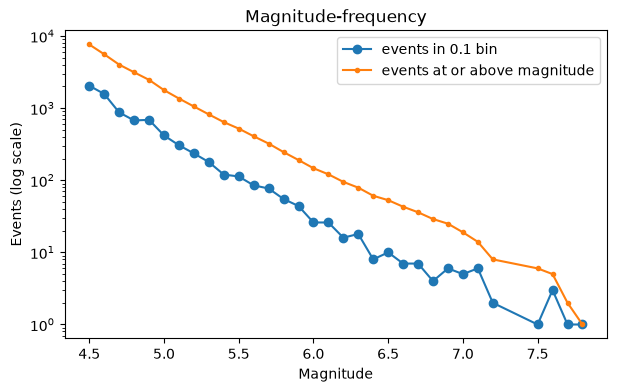

mag,4.5,4.6,4.7,4.8,4.9,5.0
events,2049,1575,873,676,689,419


In [8]:
events = load_earthquakes()  # drops non-earthquake events with a warning
print(f"{len(events)} earthquakes kept of {len(raw)} events")

per_bin = events["mag"].round(1).value_counts().sort_index()
at_least = per_bin[::-1].cumsum()[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(per_bin.index, per_bin.values, marker="o", label="events in 0.1 bin")
ax.semilogy(at_least.index, at_least.values, marker=".", label="events at or above magnitude")
ax.set(xlabel="Magnitude", ylabel="Events (log scale)", title="Magnitude-frequency")
ax.legend()
plt.show()
per_bin.head(6).to_frame("events").T

In [9]:
error_columns = ["nst", "gap", "dmin", "horizontalError", "magError", "magNst"]
blank = raw[error_columns].isna().any(axis=1)
pd.DataFrame(
    {
        "events": raw["net"].value_counts(),
        "with a blank station or error column": raw.loc[blank, "net"].value_counts(),
    }
).fillna(0).astype(int).sort_values("events", ascending=False)

,events,with a blank station or error column
net,,
us,7598,47
ak,30,30
nc,9,9
pr,5,0
ci,3,3
hv,3,3
tx,2,0
nn,1,1


**Observations**

- Counts per 0.1 magnitude fall from 2,049 at 4.5 to 1 at 7.8, and both lines are close to straight on the log scale from 4.5 upward. There is no drop at the low end, so no sign that events near 4.5 are missed. The 4.8 and 4.9 bins (676 and 689) are a small wobble.
- Blank station or error columns come from networks other than `us`: all 30 `ak`, 9 `nc`, 3 `ci`, 3 `hv` and 1 `nn` events, but only 47 of 7,598 `us` events and none from `pr` or `tx`.
- An area of the map with no rows had no magnitude 4.5+ earthquake in the catalogue for 2023; it is not missing data.
- **Decision:** no action on the blank columns; they are not clustering features.

## 3. Raw data visualised

### Where the earthquakes are

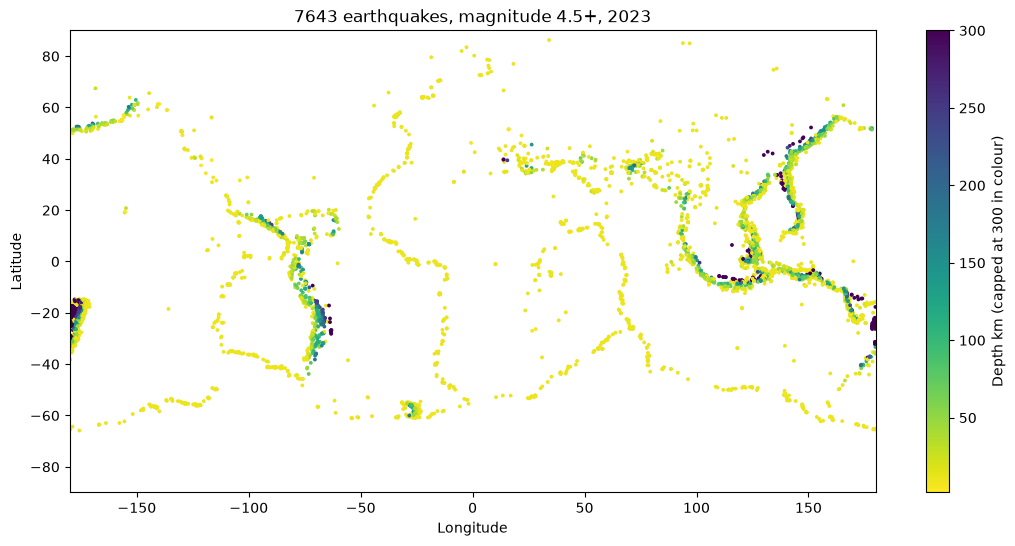

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
points = ax.scatter(events["longitude"], events["latitude"], c=events["depth"], s=3, cmap="viridis_r", vmax=300)
fig.colorbar(points, ax=ax, label="Depth km (capped at 300 in colour)")
ax.set(xlabel="Longitude", ylabel="Latitude", xlim=(-180, 180), ylim=(-90, 90), title=f"{len(events)} earthquakes, magnitude 4.5+, 2023")
ax.axvline(180, color="grey", lw=0.5)
plt.show()

**Observations**

- Earthquakes lie on narrow lines: around the Pacific (western Americas, Alaska and the Aleutians, Japan, the Philippines, Indonesia, Tonga and Fiji) and along thin lines in the oceans (the Atlantic, Indian and southern Pacific oceans). Most of the map, including continental interiors and ocean basins, has no events.
- Deep events (dark colours) appear only in some lines: western South America, Tonga and Fiji, and from Indonesia to Japan. The ocean lines are all shallow (yellow).
- The Tonga and Fiji group appears at both the left and right edges of the map: one group of earthquakes split by the 180 degree line.
- These thin, curved, dense lines with empty space between them are the density structure found in screening.

### Depth and magnitude distributions

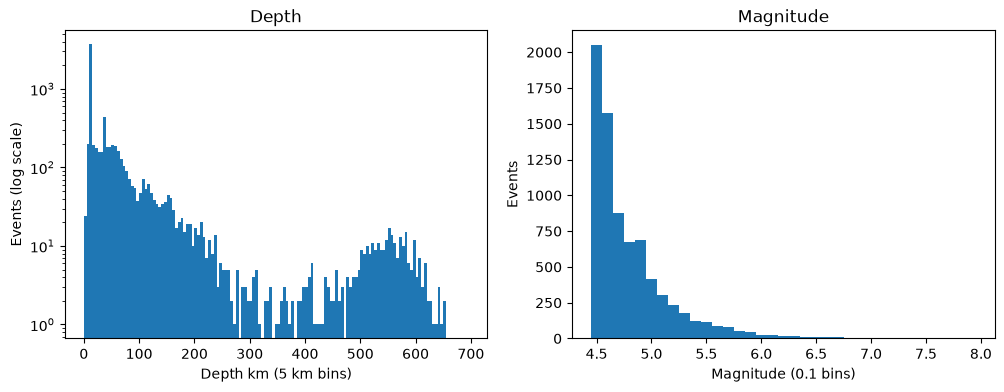

depth,"(0, 20]","(20, 70]","(70, 300]","(300, 700]"
events,4104,1957,1248,334


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(events["depth"], bins=np.arange(0, 700, 5), log=True)
axes[0].set(xlabel="Depth km (5 km bins)", ylabel="Events (log scale)", title="Depth")
axes[1].hist(events["mag"], bins=np.arange(4.45, 8.0, 0.1))
axes[1].set(xlabel="Magnitude (0.1 bins)", ylabel="Events", title="Magnitude")
plt.show()
pd.cut(events["depth"], [0, 20, 70, 300, 700]).value_counts().sort_index().to_frame("events").T

**Observations**

- Depth is concentrated near the surface: 4,104 earthquakes (53.7%) are at 20 km or shallower, 1,957 at 20 to 70 km, 1,248 at 70 to 300 km and 334 (4.4%) deeper than 300 km.
- The tallest depth bar is the 10 to 15 km bin, which holds the 3,375 events at exactly 10 km (section 4). Below 300 km there are few events until a second group at about 450 to 650 km.
- Magnitude is strongly right-skewed: the 4.5 bin alone holds 2,049 earthquakes (26.8%).

### Events over time

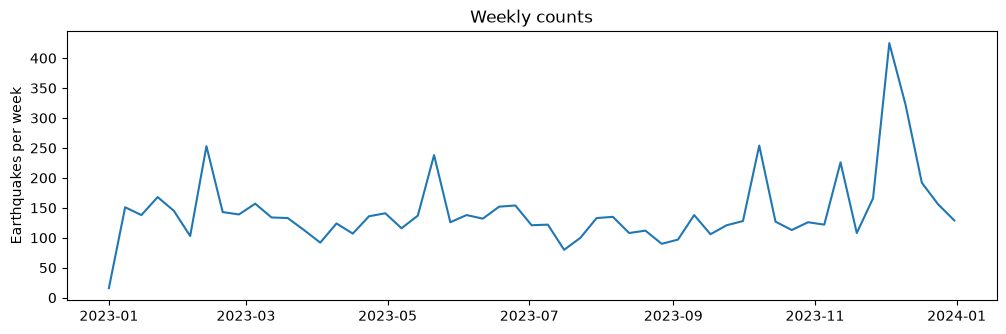

,week ending,events,top region,events in top region,largest event
0,2023-12-03,425,Philippines,143,"M7.6 19 km E of Gamut, Philippines"
1,2023-12-10,322,Philippines,265,"M7.1 118 km S of Isangel, Vanuatu"
2,2023-10-08,254,Japan region,117,"M6.9 48 km SE of Madang, Papua New Guinea"


median events per week: 133.0


In [12]:
events["time"] = pd.to_datetime(events["time"])
events["region"] = region_from_place(events["place"])

weekly = events.set_index("time").resample("W")["id"].count()
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(weekly.index, weekly.values)
ax.set(ylabel="Earthquakes per week", title="Weekly counts")
plt.show()

busiest = weekly.nlargest(3)
rows = []
for week_end, count in busiest.items():
    in_week = events[(events["time"] > week_end - pd.Timedelta(days=7)) & (events["time"] <= week_end)]
    region_counts = in_week["region"].value_counts()
    top_region, top_count = region_counts.index[0], region_counts.iloc[0]
    largest = in_week.loc[in_week["mag"].idxmax()]
    rows.append({"week ending": week_end.date(), "events": count, "top region": top_region, "events in top region": top_count, "largest event": f"M{largest['mag']} {largest['place']}"})
display(pd.DataFrame(rows))
print("median events per week:", weekly.median())

**Observations**

- The median is 133 earthquakes per week. The first point (16) is a partial week ending 1 January.
- The busiest weeks end on 3 December (425 earthquakes, 143 in the Philippines, largest the M7.6 19 km E of Gamut, Philippines) and 10 December (322, of which 265 in the Philippines).
- Other spikes appear in February, May, October and November. February is the week of the M7.8 Kahramanmaras earthquake in Turkey and May the week of the M7.7 southeast of the Loyalty Islands (section 8).
- So some dense patches on the map are aftershock sequences in a few weeks after one large earthquake, not activity spread over the year. Section 9 checks how much this changes the map.

## 4. Depth values

The USGS definition says a poorly constrained depth may be fixed at a default value. If many events share
a default depth, depth values would group events by how they were located, not by where they are.

In [13]:
top_depths = events["depth"].value_counts().head(6)
display(top_depths.to_frame("events").assign(**{"% of events": 100 * top_depths / len(events)}).T)

fixed = events["depth"].isin([10.0, 35.0])
pd.concat(
    {
        "depth 10 km": events.loc[events["depth"] == 10.0, "depthError"].describe(),
        "depth 35 km": events.loc[events["depth"] == 35.0, "depthError"].describe(),
        "all other depths": events.loc[~fixed, "depthError"].describe(),
    },
    axis=1,
).T

depth,10.0,35.0,9.0,8.0,13.0,11.0
events,3375.000,270.000,12.000,11.000,11.000,9.000
% of events,44.158,3.533,0.157,0.144,0.144,0.118


,count,mean,std,min,25%,50%,75%,max
depth 10 km,3375.0,1.845,0.737,0.528,1.808,1.856,1.891,31.610
depth 35 km,270.0,1.857,0.134,0.980,1.840,1.885,1.917,2.012
all other depths,3998.0,5.386,2.162,0.100,4.082,5.381,6.761,31.610


**Observations**

- 3,375 earthquakes (44.2%) have depth exactly 10.0 km and 270 (3.5%) exactly 35.0 km. The next most common value, 9.0 km, has 12.
- Their reported depth uncertainty is nearly constant: median 1.856 km (IQR 1.808 to 1.891) at 10 km and 1.885 km (IQR 1.840 to 1.917) at 35 km, against median 5.381 km (IQR 4.082 to 6.761) for all other depths.
- The USGS definition names 10 km as a default depth. 35 km is not named on that page, but it shows the same pattern, so it is probably also a default.
- **Decision:** depth is not a clustering feature. About 48% of values are probably defaults, so depth would group earthquakes by how they were located. Depth is kept to describe clusters.

## 5. From coordinates to features

Clustering needs a distance between two events. Treating latitude and longitude as flat x and y has two
problems, shown on real pairs below:
- **the 180 degree line:** longitude 179.9 and -179.9 are 0.2 degrees apart on the ground but 359.8 apart as numbers;
- **shrinking longitude:** one degree of longitude is about 111 km at the equator and about half that at latitude 60.

Two representations fix both: latitude and longitude in radians with the haversine (great-circle) distance,
which DBSCAN and HDBSCAN accept; and 3D unit vectors, for K-means, which only supports Euclidean distance.

In [14]:
east = events[events["longitude"] > 175]
west = events[events["longitude"] < -175]
cross = haversine_km(
    east["latitude"].to_numpy()[:, None], east["longitude"].to_numpy()[:, None],
    west["latitude"].to_numpy()[None, :], west["longitude"].to_numpy()[None, :],
)
i, j = np.unravel_index(np.argmin(cross), cross.shape)
dateline_pair = (east.iloc[i], west.iloc[j])

high = events[events["latitude"] > 60].sort_values("longitude")
steps = haversine_km(high["latitude"].values[:-1], high["longitude"].values[:-1], high["latitude"].values[1:], high["longitude"].values[1:])
k = int(np.argmin(np.abs(np.diff(high["longitude"].values) - 5)))
high_pair = (high.iloc[k], high.iloc[k + 1])

rows = []
for name, (a, b) in {"closest pair across the 180 degree line": dateline_pair, "pair about 5 degrees of longitude apart above latitude 60": high_pair}.items():
    ua, ub = to_unit_vectors([a["latitude"], b["latitude"]], [a["longitude"], b["longitude"]])
    rows.append(
        {
            "pair": name,
            "event A": f"({a['latitude']:.2f}, {a['longitude']:.2f}) {a['place']}",
            "event B": f"({b['latitude']:.2f}, {b['longitude']:.2f}) {b['place']}",
            "flat distance (degrees)": float(np.hypot(a["latitude"] - b["latitude"], a["longitude"] - b["longitude"])),
            "flat distance x 111.2 km": 111.2 * float(np.hypot(a["latitude"] - b["latitude"], a["longitude"] - b["longitude"])),
            "great-circle km": float(haversine_km(a["latitude"], a["longitude"], b["latitude"], b["longitude"])),
            "unit-vector chord x Earth radius km": EARTH_RADIUS_KM * float(np.linalg.norm(ua - ub)),
        }
    )
display(pd.DataFrame(rows).T)

near_line = (events["longitude"].abs() > 170).mean()
print(f"events with |longitude| > 170: {near_line:.1%}; events above latitude 60 or below -60: {(events['latitude'].abs() > 60).mean():.1%}")

,0,1
pair,closest pair across the 180 degree line,pair about 5 degrees of longitude apart above ...
event A,"(-23.98, 179.95) south of the Fiji Islands","(61.72, -149.55) 10 km NNE of Meadow Lakes, Al..."
event B,"(-23.98, -179.99) south of the Fiji Islands","(65.58, -144.48) 14 km E of Central, Alaska"
flat distance (degrees),359.94,6.368
flat distance x 111.2 km,40025.361,708.171
great-circle km,6.071,495.979
unit-vector chord x Earth radius km,6.071,495.854


events with |longitude| > 170: 17.2%; events above latitude 60 or below -60: 2.2%


**Observations**

- **180 degree line:** two earthquakes south of the Fiji Islands at (-23.98, 179.95) and (-23.98, -179.99) are 6.07 km apart, but 359.94 degrees apart as flat coordinates (40,025 km if scaled). A flat distance puts them on opposite sides of the map.
- **Shrinking longitude:** two Alaska earthquakes are 6.37 flat degrees apart (708 km if scaled) but 496 km apart on the ground, so the flat distance is 43% too large.
- The unit-vector chord times the Earth radius gives 6.071 km and 495.854 km, within 0.03% of the great-circle distance.
- 17.2% of earthquakes have longitude beyond 170 or -170, so the 180 degree line affects a large share of the data. 2.2% are beyond latitude 60 or -60.
- **Decision:** DBSCAN and HDBSCAN use latitude and longitude in radians with `metric="haversine"`; K-means uses 3D unit vectors (`to_unit_vectors`). The Stage 0 silhouette test (`experiments/screening.py`) used flat degrees and must be rerun on unit vectors.

## 6. Spacing between events (density)

DBSCAN uses one distance (`eps`) for the whole map; HDBSCAN adapts to local density. The spread of
nearest-neighbour distances shows how much density varies. The k-th nearest-neighbour distance (k = 5, 10, 20)
is the curve DBSCAN's `eps` is chosen from in Stage 3.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
k=1,7643.0,27.449,70.622,0.095,0.517,1.245,3.874,9.896,24.891,100.490,285.245,2175.739
k=5,7643.0,85.787,168.693,1.333,2.810,4.533,13.172,36.666,92.365,311.032,794.738,3703.619
k=10,7643.0,133.917,215.598,2.106,4.445,6.968,21.969,64.985,154.664,492.944,993.670,3777.276
k=20,7643.0,218.982,306.546,3.997,6.521,10.252,40.037,104.852,243.966,838.078,1423.228,3869.580


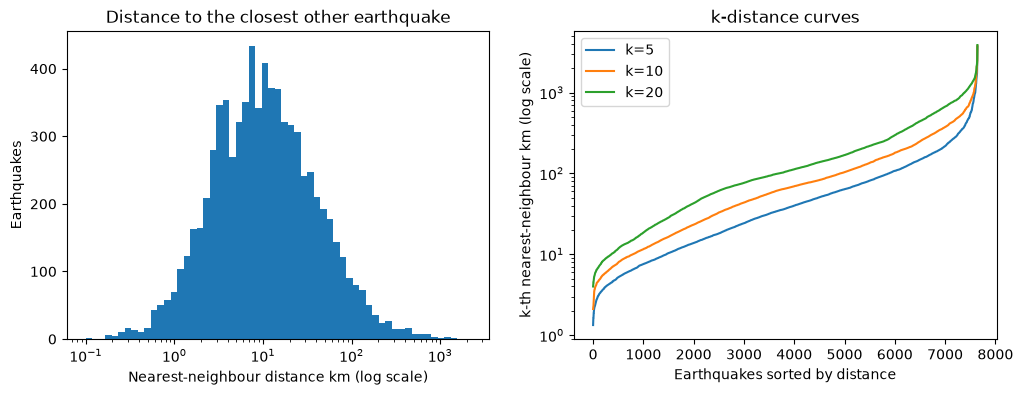

In [15]:
spacing = pd.DataFrame({f"k={k}": nearest_neighbour_km(events["latitude"], events["longitude"], k=k) for k in (1, 5, 10, 20)})
display(spacing.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(spacing["k=1"], bins=np.logspace(-1, np.log10(spacing["k=1"].max()), 60))
axes[0].set(xscale="log", xlabel="Nearest-neighbour distance km (log scale)", ylabel="Earthquakes", title="Distance to the closest other earthquake")
for column in ["k=5", "k=10", "k=20"]:
    axes[1].plot(np.sort(spacing[column].to_numpy()), label=column)
axes[1].set(yscale="log", xlabel="Earthquakes sorted by distance", ylabel="k-th nearest-neighbour km (log scale)", title="k-distance curves")
axes[1].legend()
plt.show()

**Observations**

- The distance to the closest other earthquake has median 9.9 km, 5th percentile 1.2 km, 95th percentile 100.5 km and maximum 2,176 km. On a log scale the histogram is roughly symmetric around 10 km and spans about four orders of magnitude.
- The median location uncertainty (8.25 km, section 1) is about the same as the median nearest-neighbour distance, so detail below about 10 km is within location error.
- The k-distance curves rise smoothly across two orders of magnitude (k = 5: 5th percentile 4.5 km, 95th percentile 311 km) and turn sharply upward only for the last few hundred earthquakes. There is no knee in the middle of the curve.
- **Implication for Stage 3:** no single `eps` separates dense from sparse areas for most of the data. A small `eps` keeps only the densest belts; a large one merges neighbouring belts. `eps` is chosen from these curves in Stage 3, and HDBSCAN, which does not need one `eps`, is compared against it.

## 7. Events per region

Region is the last part of `place` with any leading "N km DIR of" removed (`region_from_place`).

261 regions; top 10 hold 49.4% of earthquakes; 78 regions have a single earthquake


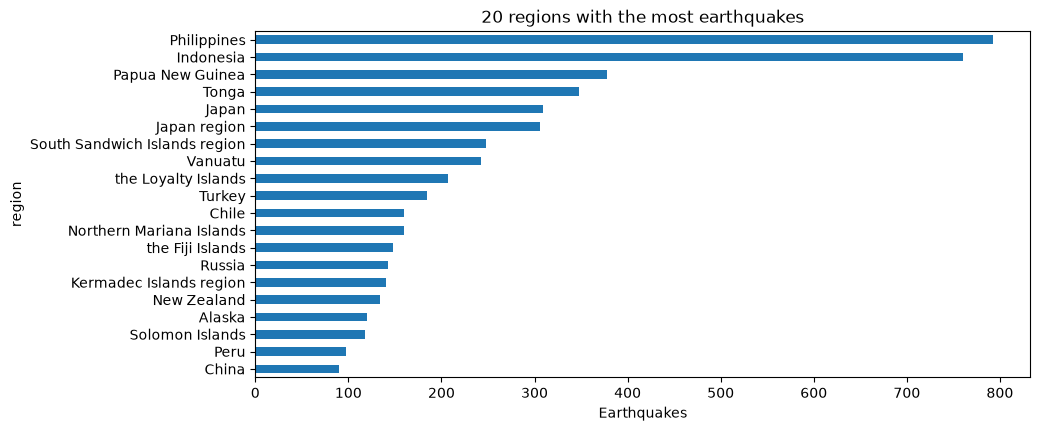

In [16]:
regions = events["region"].value_counts()
print(f"{len(regions)} regions; top 10 hold {regions.head(10).sum() / len(events):.1%} of earthquakes; {(regions == 1).sum()} regions have a single earthquake")
fig, ax = plt.subplots(figsize=(10, 4.5))
regions.head(20)[::-1].plot.barh(ax=ax)
ax.set(xlabel="Earthquakes", title="20 regions with the most earthquakes")
plt.show()

**Observations**

- 261 regions; the 10 busiest hold 49.4% of earthquakes, and 78 regions have a single earthquake. The Philippines and Indonesia each have more than 750.
- Region names are not consistent: "Japan" (309) and "Japan region" (306) are counted separately. Region is used only to name clusters, never as a feature.
- K-means minimises squared distance summed over earthquakes, so the busiest regions have the most weight in where centroids end up.

## 8. Outliers and extremes

In [17]:
events["nearest km"] = spacing["k=1"].to_numpy()
display(Markdown("**10 most isolated earthquakes**"))
display(events.nlargest(10, "nearest km")[["time", "latitude", "longitude", "depth", "mag", "place", "nearest km"]])
display(Markdown("**5 largest earthquakes**"))
display(events.nlargest(5, "mag")[["time", "latitude", "longitude", "depth", "mag", "place"]])
display(Markdown("**Deepest earthquakes**"))
display(events.nlargest(5, "depth")[["time", "latitude", "longitude", "depth", "mag", "place"]])

**10 most isolated earthquakes**

,time,latitude,longitude,depth,mag,place,nearest km
3268,2023-06-11 10:23:22.496000+00:00,-18.479,-135.839,10.000,4.8,"Tuamotu Archipelago, French Polynesia region",2175.739
2169,2023-04-19 16:07:01.146000+00:00,32.620,-70.836,10.000,4.5,off the east coast of the United States,1431.617
552,2023-01-26 04:16:05.416000+00:00,16.615,-25.619,10.000,5.3,Cape Verde,1389.616
72,2023-01-04 02:02:10.369000+00:00,0.076,170.032,10.000,5.0,"Gilbert Islands, Kiribati region",1257.080
2989,2023-05-27 03:27:51.559000+00:00,-0.703,-60.293,10.000,4.6,"230 km NNW of Rio Preto da Eva, Brazil",1241.486
2005,2023-04-09 21:12:48.087000+00:00,-38.472,-55.640,10.000,4.5,"175 km ESE of Mar del Plata, Argentina",1230.294
1836,2023-03-29 22:55:55.861000+00:00,25.330,36.079,9.106,4.5,"108 km SSW of Al Wajh, Saudi Arabia",1093.827
268,2023-01-14 04:26:06.741000+00:00,-37.373,30.988,10.000,4.6,off the coast of South Africa,907.321
3193,2023-06-07 12:13:05.439000+00:00,-16.773,147.025,10.451,4.5,"122 km ENE of Yarrabah, Australia",821.064
4629,2023-08-30 17:58:51.266000+00:00,67.459,-168.486,26.400,4.5,"123 km SW of Point Hope, Alaska",802.802


**5 largest earthquakes**

,time,latitude,longitude,depth,mag,place
721,2023-02-06 01:17:34.342000+00:00,37.226,37.014,10.000,7.8,"Pazarcik earthquake, Kahramanmaras earthquake ..."
2700,2023-05-19 02:57:03.172000+00:00,-23.206,170.742,18.053,7.7,southeast of the Loyalty Islands
175,2023-01-09 17:47:35.037000+00:00,-7.059,130.009,104.950,7.6,"Pulau Pulau Tanimbar, Indonesia"
2553,2023-05-10 16:02:00.334000+00:00,-15.628,-174.493,210.000,7.6,"82 km WNW of Hihifo, Tonga"
6556,2023-12-02 14:37:04.454000+00:00,8.527,126.416,40.000,7.6,"19 km E of Gamut, Philippines"


**Deepest earthquakes**

,time,latitude,longitude,depth,mag,place
3754,2023-07-05 09:56:51.605000+00:00,-19.326,-179.198,653.516,4.7,"209 km SE of Levuka, Fiji"
4862,2023-09-13 05:34:33.417000+00:00,-5.754,110.175,650.655,5.0,"100 km NW of Batang, Indonesia"
4204,2023-08-03 18:05:53.276000+00:00,1.110,120.294,646.537,4.5,"228 km NNE of Palu, Indonesia"
4724,2023-09-06 15:52:16.189000+00:00,41.490,130.078,644.879,4.9,"34 km E of Hoemul-li, North Korea"
1865,2023-04-01 18:11:20.621000+00:00,-12.924,169.321,642.662,4.8,"218 km ENE of Sola, Vanuatu"


**Observations**

- The most isolated earthquakes are far from any belt: Tuamotu Archipelago (2,176 km from the nearest earthquake), off the east coast of the United States (1,432 km), Cape Verde (1,390 km), Gilbert Islands (1,257 km), Brazil (1,241 km) and off Argentina (1,230 km). 7 of the 10 have depth exactly 10.000 km.
- The largest are M7.8 Pazarcik (Kahramanmaras sequence, 6 February), M7.7 southeast of the Loyalty Islands (19 May), and three M7.6 (Tanimbar in Indonesia, Tonga, and the Philippines on 2 December).
- The deepest are 642.7 to 653.5 km, under Fiji, Indonesia (two), North Korea and Vanuatu.
- **Decision:** keep all of them. They are reviewed events with valid coordinates; isolated earthquakes are real and are the points density methods should label as noise.

## 9. Stability over time

If the dense areas are a property of the plate boundaries, the same map cells should be busy in both halves
of the year. Aftershock sequences add short-lived dense patches. Counts per 5 by 5 degree cell are compared
between January to June and July to December.

510 cells with at least one earthquake; 293 (57%) have earthquakes in both halves
share of earthquakes in cells active in both halves: 94.5%
correlation of log(1 + count) between halves: 0.72


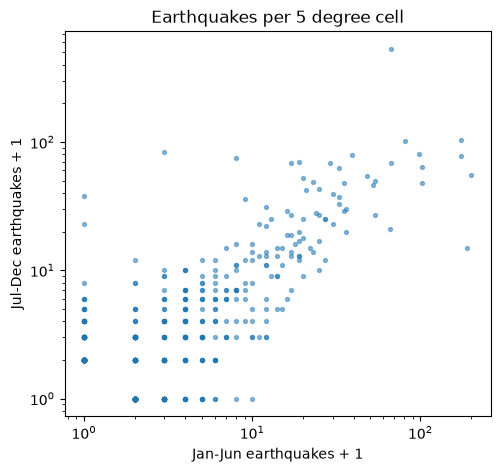

,period,Jan-Jun,Jul-Dec,difference,main region
cell_lat,cell_lon,,,,
5.0,125.0,66,534,468,Philippines
35.0,35.0,188,14,-174,Turkey
-25.0,170.0,200,54,-146,the Loyalty Islands
0.0,125.0,174,77,-97,Indonesia
20.0,145.0,2,82,80,Northern Mariana Islands


In [18]:
half = np.where(events["time"].dt.month <= 6, "Jan-Jun", "Jul-Dec")
cells = grid_cell_counts(events["latitude"], events["longitude"], half)
both = (cells > 0).all(axis=1)
print(f"{len(cells)} cells with at least one earthquake; {both.sum()} ({both.mean():.0%}) have earthquakes in both halves")
print(f"share of earthquakes in cells active in both halves: {cells[both].to_numpy().sum() / cells.to_numpy().sum():.1%}")
print(f"correlation of log(1 + count) between halves: {np.corrcoef(np.log1p(cells['Jan-Jun']), np.log1p(cells['Jul-Dec']))[0, 1]:.2f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(cells["Jan-Jun"] + 1, cells["Jul-Dec"] + 1, s=8, alpha=0.5)
ax.set(xscale="log", yscale="log", xlabel="Jan-Jun earthquakes + 1", ylabel="Jul-Dec earthquakes + 1", title="Earthquakes per 5 degree cell")
plt.show()

changed = cells.assign(difference=cells["Jul-Dec"] - cells["Jan-Jun"]).reindex(
    (cells["Jul-Dec"] - cells["Jan-Jun"]).abs().sort_values(ascending=False).index
).head(5)
changed["main region"] = [
    events.loc[(np.floor(events["latitude"] / 5) * 5 == lat) & (np.floor(events["longitude"] / 5) * 5 == lon), "region"].value_counts().index[0]
    for lat, lon in changed.index
]
changed

**Observations**

- 510 cells have at least one earthquake. Only 293 (57%) have earthquakes in both halves of the year, but those cells hold 94.5% of all earthquakes; the cells active in one half are mostly sparse.
- The correlation of log(1 + count) between halves is 0.72: busy cells stay busy.
- The largest changes are aftershock sequences: the Philippines cell grows from 66 to 534, Turkey falls from 188 to 14, the Loyalty Islands from 200 to 54 and Indonesia from 174 to 77; the Northern Mariana Islands cell rises from 2 to 82.
- So the belts are stable across the year, but the density of individual patches depends on which large earthquakes fell in the window.
- **Decision:** keep the full year, without removing aftershocks. Stage 4 robustness check: cluster each half separately and compare. Report the Philippines (December) and Turkey (February) patches as aftershock-driven when they appear as clusters.

## 10. Minimum magnitude threshold

In [19]:
magnitude_threshold_table(events)

,min magnitude,events,% kept,median nearest neighbour km
0,4.5,7643,100.000,9.896
1,5.0,1780,23.289,16.417
2,5.5,520,6.804,59.492
3,6.0,147,1.923,122.806


**Observations**

- Raising the minimum magnitude removes most of the data: 5.0 keeps 1,780 earthquakes (23.3%), 5.5 keeps 520 (6.8%) and 6.0 keeps 147 (1.9%).
- The median nearest-neighbour distance grows from 9.9 km to 16.4, 59.5 and 122.8 km: fewer events make the belts sparser, leaving density methods less to find.
- Section 2 showed no shortfall of events at 4.5, so there is no completeness reason to raise the cutoff.
- **Decision:** keep magnitude 4.5 and above (`DEFAULT_MIN_MAGNITUDE`). Magnitude 5.0 and above (1,780 earthquakes) is available as a Stage 4 ablation.

## 11. Dimensionality

The clustering features are the epicentre only: 2 numbers per earthquake (latitude and longitude), or 3
numbers on the unit sphere that still have 2 degrees of freedom. PCA has nothing to remove.
Depth, magnitude and time are not clustering features (sections 4 and 9); they are kept to describe clusters.

## 12. Summary of preprocessing decisions

| Issue | Evidence | Decision |
|---|---|---|
| Non-earthquake events | 8 volcanic eruptions near Saipan, 14 and 15 September | Dropped with a warning (`load_earthquakes`) |
| Blank station and error columns | At most 1.2% per column, mostly non-`us` networks | No action; not features |
| Default depths | 44.2% at exactly 10 km, 3.5% at 35 km, depth uncertainty nearly constant at both | Depth is not a feature; kept to describe clusters |
| 180 degree line and shrinking longitude | Pair 6.07 km apart is 359.94 flat degrees apart; 17.2% of earthquakes beyond 170 or -170 longitude | Haversine on radians (DBSCAN, HDBSCAN); 3D unit vectors (K-means) |
| Density varies widely | Nearest-neighbour 5th to 95th percentile 1.2 to 100.5 km; k-distance curves have no knee | Choose `eps` from k-distance curves; compare with HDBSCAN |
| Location uncertainty | Median `horizontalError` 8.25 km, median nearest neighbour 9.9 km | Do not interpret structure below about 10 km |
| Aftershock sequences | Philippines cell 66 to 534, Turkey 188 to 14 between halves; belts stable (94.5% of earthquakes in cells active in both halves) | Keep full year; cluster each half separately in Stage 4 |
| Minimum magnitude | No shortfall at 4.5; 5.0 keeps 23.3% | Keep 4.5; 5.0 as an ablation |
| Isolated earthquakes | Up to 2,176 km from the nearest earthquake | Keep; expected noise for density methods |
| Inconsistent region names | "Japan" and "Japan region" | Names only for describing clusters |

**Next (Stage 2):** switch `experiments/screening.py` to unit vectors for the silhouette test and haversine for HDBSCAN, then start the Stage 3 parameter sweeps.